# 03 — Models B & C: Uplift Modelling (T-learner and S-learner)

Train proper uplift models and show they outperform propensity-based targeting
on the Qini metric.

**T-learner**: two separate models on treated/control splits.  
**S-learner**: one model with treatment as a feature and treatment×feature interactions.

Both estimate the Conditional Average Treatment Effect (CATE):
$$\hat{\tau}(X) = \hat{\mu}_1(X) - \hat{\mu}_0(X)$$

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parents[2] / "src"))  # commerce-ml-lab/src
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))  # 03_checkout_intent/src

import warnings

warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from commerce_ml.viz.plotting import apply_style, PALETTE
from intent.models import PropensityModel, TLearner, SLearner
from intent.features import temporal_split
from intent.evaluate import (
    qini_coefficient,
    qini_curve,
    uplift_at_k,
    policy_comparison,
    incremental_conversions_at_k,
)

apply_style()
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)

df = pd.read_parquet(RESULTS / "uplift_data.parquet")
train, test = temporal_split(df, test_frac=0.20, random_state=42)
y, w = test["conversion"].values, test["treatment"].values

propensity_model = PropensityModel.load(RESULTS / "propensity_model.pkl")
propensity_scores = propensity_model.predict_proba(test)

print(f"Test: {len(test):,} rows | ATE: {(y[w == 1].mean() - y[w == 0].mean()):+.4f}")

Test: 279,454 rows | ATE: +0.0008


## Train T-learner and S-learner

In [2]:
t_learner = TLearner()
t_learner.fit(train)
t_scores = t_learner.predict_cate(test)

s_learner = SLearner()
s_learner.fit(train)
s_scores = s_learner.predict_cate(test)

rand_scores = np.random.default_rng(0).random(len(test))

print(f"T-learner CATE range: [{t_scores.min():.3f}, {t_scores.max():.3f}]")
print(f"S-learner CATE range: [{s_scores.min():.3f}, {s_scores.max():.3f}]")

for name, scores in [
    ("T-learner", t_scores),
    ("S-learner", s_scores),
    ("Propensity", propensity_scores),
    ("Random", rand_scores),
]:
    q = qini_coefficient(y, w, scores)
    u20 = uplift_at_k(y, w, scores, k=0.20)
    print(f"  {name:12s}  Qini={q:+6.3f}  Uplift@20%={u20:+.4f}")

T-learner CATE range: [-0.921, 0.961]
S-learner CATE range: [-1.000, 1.000]
  T-learner     Qini=+66.088  Uplift@20%=+0.0031
  S-learner     Qini=+74.192  Uplift@20%=+0.0036
  Propensity    Qini=+88.092  Uplift@20%=+0.0036
  Random        Qini=+30.152  Uplift@20%=+0.0018


## Qini curves: uplift models vs propensity targeting

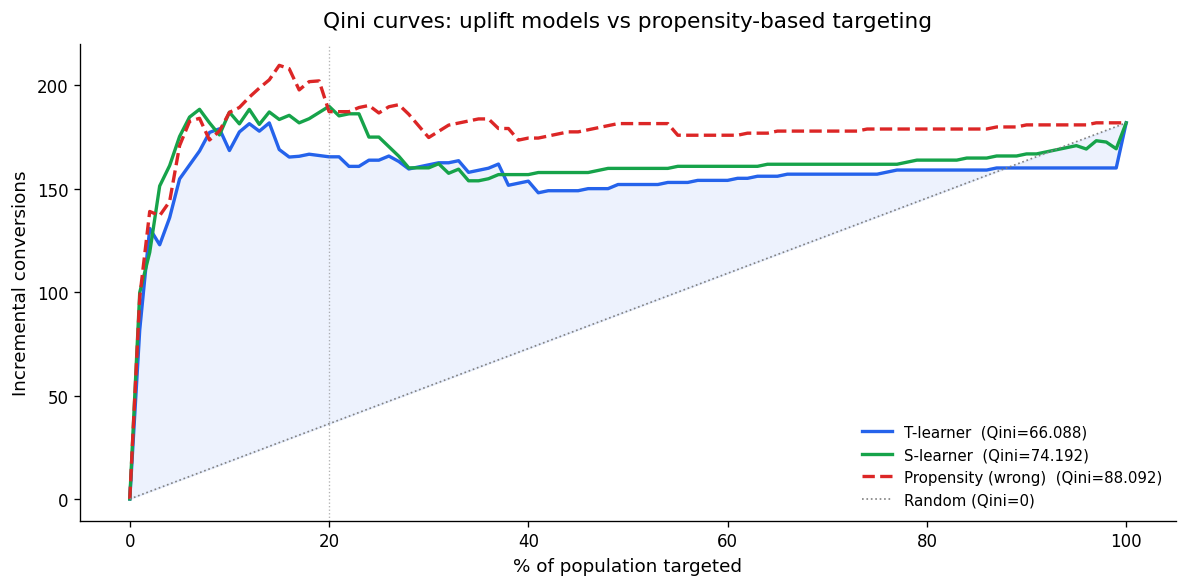

In [4]:
curves = {
    "T-learner": qini_curve(y, w, t_scores),
    "S-learner": qini_curve(y, w, s_scores),
    "Propensity (wrong)": qini_curve(y, w, propensity_scores),
}
colors = {
    "T-learner": PALETTE[0],
    "S-learner": PALETTE[1],
    "Propensity (wrong)": PALETTE[2],
}

fig, ax = plt.subplots(figsize=(10, 5))
for name, curve in curves.items():
    q = qini_coefficient(
        y, w, t_scores if "T-" in name else s_scores if "S-" in name else propensity_scores
    )
    ax.plot(
        curve["fraction_targeted"] * 100,
        curve["incremental_conversions"],
        color=colors[name],
        linewidth=2,
        linestyle="--" if "Propensity" in name else "-",
        label=f"{name}  (Qini={q:.3f})",
    )

rand_curve = curves["T-learner"]
ax.plot(
    rand_curve["fraction_targeted"] * 100,
    rand_curve["random_baseline"],
    color="grey",
    linewidth=1,
    linestyle=":",
    label="Random (Qini=0)",
)
ax.fill_between(
    curves["T-learner"]["fraction_targeted"] * 100,
    curves["T-learner"]["incremental_conversions"],
    curves["T-learner"]["random_baseline"],
    alpha=0.08,
    color=PALETTE[0],
)

ax.axvline(20, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
ax.set_xlabel("% of population targeted")
ax.set_ylabel("Incremental conversions")
ax.set_title("Qini curves: uplift models vs propensity-based targeting")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / "uplift_qini_comparison.png", dpi=120)
plt.show()

## Policy comparison: incremental revenue at different budget levels

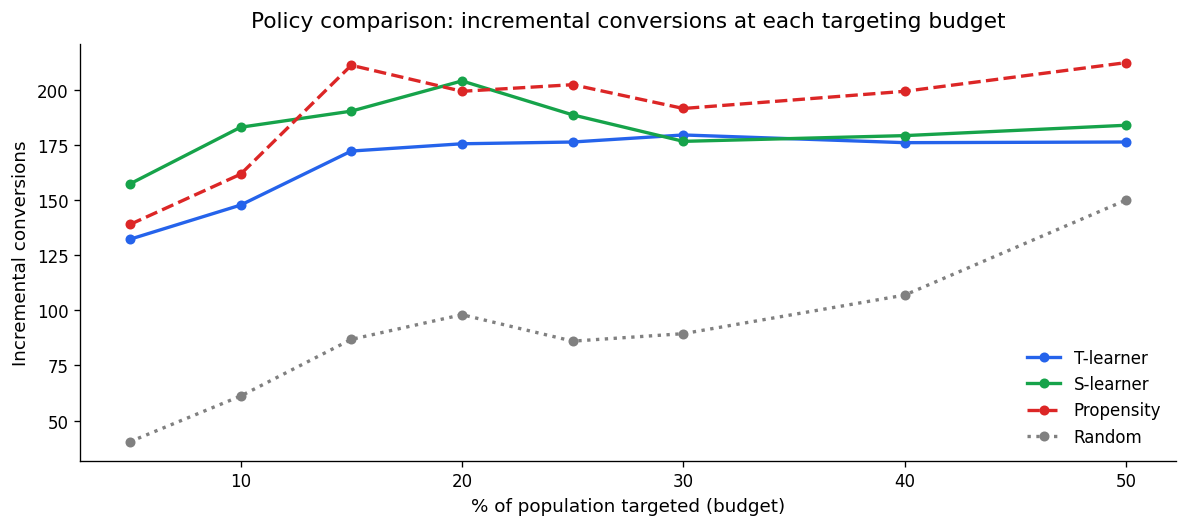

At 20% targeting budget:
     model  uplift_at_k  incremental_conversions
 T-learner     0.003140                    175.5
 S-learner     0.003650                    204.0
Propensity     0.003566                    199.3
    Random     0.001754                     98.0


In [5]:
comp = policy_comparison(
    y,
    w,
    {
        "T-learner": t_scores,
        "S-learner": s_scores,
        "Propensity": propensity_scores,
        "Random": rand_scores,
    },
    k_values=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50],
)

fig, ax = plt.subplots(figsize=(10, 4.5))
for model_name, color, ls in [
    ("T-learner", PALETTE[0], "-"),
    ("S-learner", PALETTE[1], "-"),
    ("Propensity", PALETTE[2], "--"),
    ("Random", "grey", ":"),
]:
    sub = comp[comp["model"] == model_name]
    ax.plot(
        sub["k"] * 100,
        sub["incremental_conversions"],
        color=color,
        linewidth=2,
        linestyle=ls,
        marker="o",
        markersize=5,
        label=model_name,
    )

ax.set_xlabel("% of population targeted (budget)")
ax.set_ylabel("Incremental conversions")
ax.set_title("Policy comparison: incremental conversions at each targeting budget")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "uplift_policy_comparison.png", dpi=120)
plt.show()

# Highlight the top-20% comparison
print("At 20% targeting budget:")
print(
    comp[comp["k"] == 0.20][["model", "uplift_at_k", "incremental_conversions"]].to_string(
        index=False
    )
)

## Where each model targets: segment composition of top-20%

In [6]:
if df["segment"].iloc[0] != "unknown":
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    k = 0.20
    for ax, (name, scores) in zip(
        axes, [("T-learner", t_scores), ("S-learner", s_scores), ("Propensity", propensity_scores)]
    ):
        top_idx = np.argsort(scores)[::-1][: int(len(test) * k)]
        seg_frac = pd.Series(test["segment"].values[top_idx]).value_counts(normalize=True)
        colors_seg = [
            PALETTE[
                2
                if s == "persuadable"
                else 0
                if s == "sure_thing"
                else 1
                if s == "lost_cause"
                else 3
            ]
            for s in seg_frac.index
        ]
        ax.bar(seg_frac.index, seg_frac.values, color=colors_seg, alpha=0.85, edgecolor="white")
        ax.set_title(f"{name}: top-{k:.0%} composition")
        ax.set_ylabel("Fraction")
        ax.set_ylim(0, 1)
        for bar, v in zip(ax.patches, seg_frac.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.0%}", ha="center", fontsize=8
            )
    plt.suptitle("Who gets targeted? Uplift models should prioritise persuadables", fontsize=9)
    plt.tight_layout()
    plt.savefig(RESULTS / "uplift_targeting_segments.png", dpi=120)
    plt.show()

In [7]:
t_learner.save(RESULTS / "t_learner.pkl")
s_learner.save(RESULTS / "s_learner.pkl")
print("Models saved.")

# Summary metrics
print("\n" + "=" * 50)
print("Summary")
print("=" * 50)
for name, scores in [
    ("T-learner", t_scores),
    ("S-learner", s_scores),
    ("Propensity", propensity_scores),
]:
    q = qini_coefficient(y, w, scores)
    u20 = uplift_at_k(y, w, scores, k=0.20)
    inc = incremental_conversions_at_k(y, w, scores, k=0.20)
    print(f"  {name:12s}  Qini={q:+.4f}  Uplift@20%={u20:+.4f}  IncrConv@20%={inc:.0f}")

Models saved.

Summary
  T-learner     Qini=+66.0885  Uplift@20%=+0.0031  IncrConv@20%=175
  S-learner     Qini=+74.1915  Uplift@20%=+0.0036  IncrConv@20%=204
  Propensity    Qini=+88.0916  Uplift@20%=+0.0036  IncrConv@20%=199
